The following code analyzes passing network data collected during the 2025 Women's Euro in Switzerland (). The analyzed dataset checks contains own and opposite team network stats and team performance indices for each match-team observation.It is checked whether different properties of the opponents' and own passing network predict offensive indices. 

# Imports

In [210]:
import pandas as pd
import numpy as np
from pathlib import Path
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM
import matplotlib.pyplot as plt
import bambi as bmb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

folder = Path("/Users/user/Dropbox/passing_network")

# Network data + other indices 

In [211]:
df2 = pd.read_excel("/Users/user/Dropbox/passing_network/tournament_data/all.xlsx")


In [212]:
df2.columns


Index(['match_id', 'match_date', 'team', 'possession_fotmob', 'xG_fotmob',
       'touches_in_opposition_box_fotmob', 'shots_on_target_fotmob',
       'accurate_passes_fotmob', 'accurate_passes_perc_fotmob',
       'possession_opponent_fotmob', 'xG_opponent_fotmob',
       'touches_in_opposition_box_opponent_fotmob',
       'shots_on_target_opponent_fotmob', 'accurate_passes_opponent_fotmob',
       'accurate_passes_perc_opponent_fotmob', 'stage', 'density',
       'degree_centralization', 'avg_clustering', 'transitivity', 'diameter',
       'convex_hull', 'total_passes', 'goals', 'shots', 'result1', 'result2',
       'shot_statsbomb_xg', 'density_opponents',
       'degree_centralization_opponents', 'avg_clustering_opponents',
       'transitivity_opponents', 'diameter_opponents', 'convex_hull_opponents',
       'total_passes_opponents', 'goals_opponents', 'shots_opponents',
       'result1_opponents', 'result2_opponents',
       'shot_statsbomb_xg_opponents'],
      dtype='str')

# Exploratory data analysis 

In [213]:
df2.describe()

,match_id,possession_fotmob,xG_fotmob,touches_in_opposition_box_fotmob,shots_on_target_fotmob,accurate_passes_fotmob,accurate_passes_perc_fotmob,possession_opponent_fotmob,xG_opponent_fotmob,touches_in_opposition_box_opponent_fotmob,...,degree_centralization_opponents,avg_clustering_opponents,transitivity_opponents,diameter_opponents,convex_hull_opponents,total_passes_opponents,goals_opponents,shots_opponents,result2_opponents,shot_statsbomb_xg_opponents
count,6.200000e+01,62.00000,62.000000,62.000000,62.000000,62.000000,62.000000,62.00000,62.000000,62.000000,...,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,52.000000,62.000000
mean,4.003442e+06,0.50000,1.723226,25.983871,5.016129,327.225806,0.767903,50.00000,1.723226,25.983871,...,0.222247,0.210967,0.915626,2.096774,2.123020,367.387097,1.709677,12.612903,0.500000,0.107824
std,8.589419e+03,0.14871,1.105332,14.767590,3.059476,148.694805,0.084546,14.87103,1.105332,14.767590,...,0.067070,0.047583,0.048767,0.298064,0.342802,145.190813,1.475339,6.047232,0.504878,0.053721
min,3.998836e+06,0.20000,0.120000,5.000000,0.000000,113.000000,0.510000,20.00000,0.120000,5.000000,...,0.088889,0.141483,0.750000,2.000000,1.199327,122.000000,0.000000,4.000000,0.000000,0.009931
25%,3.998843e+06,0.42000,0.940000,15.250000,3.000000,225.000000,0.730000,42.00000,0.940000,15.250000,...,0.177778,0.168933,0.887755,2.000000,1.893059,269.250000,1.000000,8.000000,0.000000,0.073612
50%,3.998851e+06,0.50000,1.525000,24.500000,4.500000,295.500000,0.770000,50.00000,1.525000,24.500000,...,0.222222,0.205073,0.923621,2.000000,2.139729,337.500000,1.000000,11.500000,0.500000,0.097586
75%,3.998859e+06,0.58000,2.450000,32.000000,7.000000,393.750000,0.820000,58.00000,2.450000,32.000000,...,0.277778,0.249870,0.947075,2.000000,2.347116,437.000000,2.000000,16.000000,1.000000,0.129416
max,4.020846e+06,0.80000,5.570000,62.000000,18.000000,717.000000,0.910000,80.00000,5.570000,62.000000,...,0.366667,0.328689,1.000000,3.000000,2.852840,768.000000,6.000000,32.000000,1.000000,0.241698


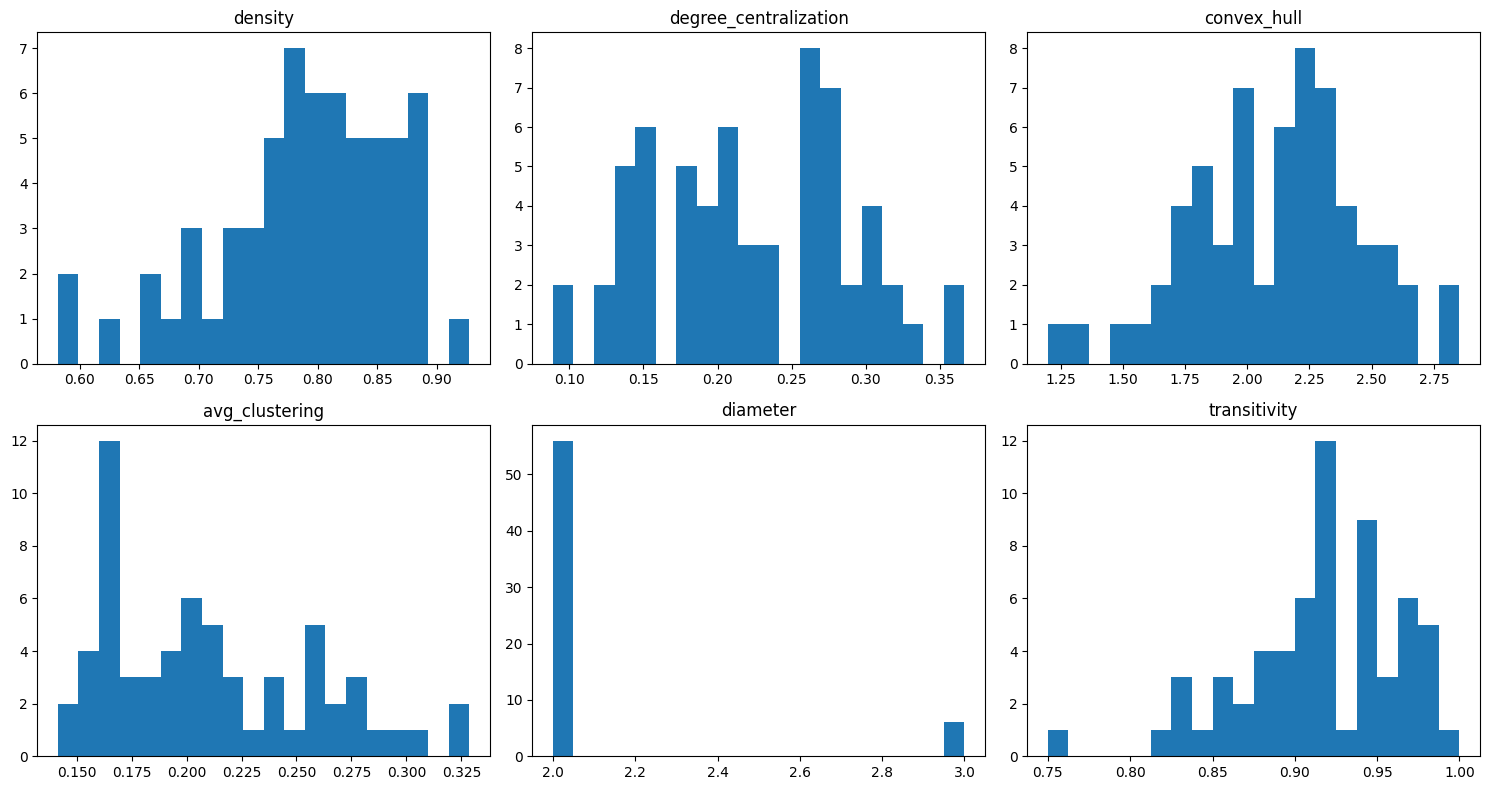

In [214]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

variables = [
    'density',
    'degree_centralization',
    'convex_hull',
    'avg_clustering',
    'diameter',
    'transitivity'
]

for ax, var in zip(axes.flatten(), variables):
    ax.hist(df2[var].dropna(), bins=20)
    ax.set_title(var)

plt.tight_layout()
plt.show()

In [215]:
df2["diff_xG_goals"] = df2["xG_fotmob"] - df2["goals"]

(array([ 1.,  1.,  1.,  3., 11.,  5., 17., 13.,  8.,  2.]),
 array([-3.14 , -2.636, -2.132, -1.628, -1.124, -0.62 , -0.116,  0.388,
         0.892,  1.396,  1.9  ]),
 <BarContainer object of 10 artists>)

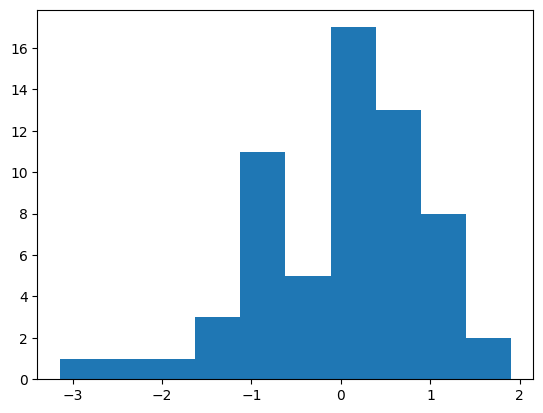

In [216]:
plt.hist(df2["diff_xG_goals"])

Min & max matches for density, degree_centralization, convex hull, avg_clustering, diameter

In [217]:
df2.loc[df2["density"].idxmin()]

match_id                                             3998847
match_date                                        2025-07-07
team                                         Belgium Women's
possession_fotmob                                        0.2
xG_fotmob                                               0.76
touches_in_opposition_box_fotmob                           5
shots_on_target_fotmob                                     3
accurate_passes_fotmob                                   113
accurate_passes_perc_fotmob                             0.62
possession_opponent_fotmob                                80
xG_opponent_fotmob                                      2.86
touches_in_opposition_box_opponent_fotmob                 59
shots_on_target_opponent_fotmob                            9
accurate_passes_opponent_fotmob                          659
accurate_passes_perc_opponent_fotmob                    0.89
stage                                            Group stage
density                 

In [218]:
df2.loc[df2["density"].idxmax()]

match_id                                            3998853
match_date                                       2025-07-10
team                                         Norway Women's
possession_fotmob                                       0.6
xG_fotmob                                              1.48
touches_in_opposition_box_fotmob                         40
shots_on_target_fotmob                                    7
accurate_passes_fotmob                                  413
accurate_passes_perc_fotmob                            0.81
possession_opponent_fotmob                               40
xG_opponent_fotmob                                     2.25
touches_in_opposition_box_opponent_fotmob                19
shots_on_target_opponent_fotmob                           5
accurate_passes_opponent_fotmob                         245
accurate_passes_perc_opponent_fotmob                   0.73
stage                                           Group stage
density                                 

In [219]:
df2.loc[df2["degree_centralization"].idxmin()]

match_id                                            3998853
match_date                                       2025-07-10
team                                         Norway Women's
possession_fotmob                                       0.6
xG_fotmob                                              1.48
touches_in_opposition_box_fotmob                         40
shots_on_target_fotmob                                    7
accurate_passes_fotmob                                  413
accurate_passes_perc_fotmob                            0.81
possession_opponent_fotmob                               40
xG_opponent_fotmob                                     2.25
touches_in_opposition_box_opponent_fotmob                19
shots_on_target_opponent_fotmob                           5
accurate_passes_opponent_fotmob                         245
accurate_passes_perc_opponent_fotmob                   0.73
stage                                           Group stage
density                                 

In [220]:
df2.loc[df2["degree_centralization"].idxmax()]

match_id                                         3998858
match_date                                    2025-07-13
team                                             Wales W
possession_fotmob                                   0.23
xG_fotmob                                           0.61
touches_in_opposition_box_fotmob                       7
shots_on_target_fotmob                                 2
accurate_passes_fotmob                               136
accurate_passes_perc_fotmob                         0.65
possession_opponent_fotmob                            77
xG_opponent_fotmob                                  5.57
touches_in_opposition_box_opponent_fotmob             58
shots_on_target_opponent_fotmob                       11
accurate_passes_opponent_fotmob                      635
accurate_passes_perc_opponent_fotmob                0.91
stage                                        Group stage
density                                              0.7
degree_centralization          

In [221]:
df2.loc[df2["convex_hull"].idxmin()]

match_id                                            3998857
match_date                                       2025-07-12
team                                         Poland Women's
possession_fotmob                                      0.46
xG_fotmob                                              2.12
touches_in_opposition_box_fotmob                         24
shots_on_target_fotmob                                    7
accurate_passes_fotmob                                  304
accurate_passes_perc_fotmob                            0.77
possession_opponent_fotmob                               54
xG_opponent_fotmob                                     2.47
touches_in_opposition_box_opponent_fotmob                26
shots_on_target_opponent_fotmob                           8
accurate_passes_opponent_fotmob                         368
accurate_passes_perc_opponent_fotmob                   0.81
stage                                           Group stage
density                                 

In [222]:
df2.loc[df2["convex_hull"].idxmax()]

match_id                                            3998843
match_date                                       2025-07-05
team                                         France Women's
possession_fotmob                                      0.43
xG_fotmob                                              2.54
touches_in_opposition_box_fotmob                         30
shots_on_target_fotmob                                    6
accurate_passes_fotmob                                  263
accurate_passes_perc_fotmob                            0.77
possession_opponent_fotmob                               57
xG_opponent_fotmob                                     0.81
touches_in_opposition_box_opponent_fotmob                24
shots_on_target_opponent_fotmob                           2
accurate_passes_opponent_fotmob                         381
accurate_passes_perc_opponent_fotmob                   0.82
stage                                           Group stage
density                                 

In [223]:
df2.loc[df2["avg_clustering"].idxmin()]

match_id                                            3998843
match_date                                       2025-07-05
team                                         France Women's
possession_fotmob                                      0.43
xG_fotmob                                              2.54
touches_in_opposition_box_fotmob                         30
shots_on_target_fotmob                                    6
accurate_passes_fotmob                                  263
accurate_passes_perc_fotmob                            0.77
possession_opponent_fotmob                               57
xG_opponent_fotmob                                     0.81
touches_in_opposition_box_opponent_fotmob                24
shots_on_target_opponent_fotmob                           2
accurate_passes_opponent_fotmob                         381
accurate_passes_perc_opponent_fotmob                   0.82
stage                                           Group stage
density                                 

In [224]:
df2.loc[df2["avg_clustering"].idxmax()]

match_id                                             4018355
match_date                                        2025-07-17
team                                         England Women's
possession_fotmob                                        0.6
xG_fotmob                                               2.58
touches_in_opposition_box_fotmob                          35
shots_on_target_fotmob                                     4
accurate_passes_fotmob                                   398
accurate_passes_perc_fotmob                             0.74
possession_opponent_fotmob                                40
xG_opponent_fotmob                                      2.04
touches_in_opposition_box_opponent_fotmob                 32
shots_on_target_opponent_fotmob                            7
accurate_passes_opponent_fotmob                          214
accurate_passes_perc_opponent_fotmob                    0.58
stage                                          Quarter-final
density                 

In [225]:
for i in range(0, len(df2)):
    if df2.loc[i, "match_id"] == 3998847:
        print(df2.loc[i, "team"])

Spain Women's
Belgium Women's


In [226]:
df2.loc[df2["diff_xG_goals"].idxmax()]

match_id                                           4018356
match_date                                      2025-07-18
team                                         Spain Women's
possession_fotmob                                     0.72
xG_fotmob                                              3.9
touches_in_opposition_box_fotmob                        56
shots_on_target_fotmob                                   6
accurate_passes_fotmob                                 581
accurate_passes_perc_fotmob                           0.88
possession_opponent_fotmob                              28
xG_opponent_fotmob                                    0.12
touches_in_opposition_box_opponent_fotmob                6
shots_on_target_opponent_fotmob                          0
accurate_passes_opponent_fotmob                        183
accurate_passes_perc_opponent_fotmob                  0.71
stage                                        Quarter-final
density                                           0.8818

In [227]:
for i in range(0, len(df2)):
    if df2.loc[i, "diff_xG_goals"] > 0:
        print(df2.loc[i, "match_id"], df2.loc[i, "team"])

4020846 England Women's
3998852 Switzerland Women's
3998840 Germany Women's
3998855 Italy Women's
3998854 Portugal Women's
4018356 Spain Women's
4018355 England Women's
3998843 France Women's
3998845 WNT Finland
3998849 Germany Women's
4020077 Spain Women's
3998850 Wales W
4018357 Germany Women's
3998852 WNT Finland
3998857 Denmark Women's
3998848 Sweden Women's
3998837 Switzerland Women's
4018357 France Women's
4020846 Spain Women's
4018354 Norway Women's
3998836 Iceland Women's
4018355 Sweden Women's
3998851 Netherlands Women's
3998841 Denmark Women's
4018356 Switzerland Women's
3998838 Italy Women's
3998838 Belgium Women's
4020005 England Women's
3998842 Wales W
3998840 Poland Women's
4020077 Germany Women's
3998841 Sweden Women's
3998846 Italy Women's
3998848 Poland Women's
3998844 Iceland Women's
4020005 Italy Women's
3998839 Portugal Women's


# Team ranks


In [233]:
df2.groupby("team")["density"].mean().sort_values(ascending = False)

team
Spain Women's          0.865152
England Women's        0.853030
Netherlands Women's    0.839394
WNT Finland            0.812121
Norway Women's         0.811364
Switzerland Women's    0.804545
Portugal Women's       0.801010
France Women's         0.790909
Italy Women's          0.774545
Germany Women's        0.773535
Wales W                0.739394
Poland Women's         0.736869
Iceland Women's        0.733333
Sweden Women's         0.731818
Denmark Women's        0.724242
Belgium Women's        0.718182
Name: density, dtype: float64

In [234]:
df2.groupby("team")["degree_centralization"].mean().sort_values(ascending = False)

team
Iceland Women's        0.285185
Wales W                0.277778
Sweden Women's         0.266667
Denmark Women's        0.255556
Italy Women's          0.251111
Poland Women's         0.245791
Portugal Women's       0.241751
Norway Women's         0.230556
France Women's         0.225000
Belgium Women's        0.222222
Switzerland Women's    0.208333
Germany Women's        0.198889
Netherlands Women's    0.196296
WNT Finland            0.188889
England Women's        0.179630
Spain Women's          0.164815
Name: degree_centralization, dtype: float64

In [235]:
df2.groupby("team")["convex_hull"].mean().sort_values(ascending = False)

team
Sweden Women's         2.580085
France Women's         2.523280
Italy Women's          2.327274
WNT Finland            2.275536
Belgium Women's        2.262368
England Women's        2.229566
Spain Women's          2.175689
Switzerland Women's    2.142255
Iceland Women's        2.131455
Norway Women's         2.120344
Denmark Women's        1.953160
Germany Women's        1.908289
Portugal Women's       1.849332
Netherlands Women's    1.800710
Wales W                1.659893
Poland Women's         1.585555
Name: convex_hull, dtype: float64

In [236]:
df2.groupby("team")["avg_clustering"].mean().sort_values(ascending = False)

team
Wales W                0.277431
Portugal Women's       0.267238
Norway Women's         0.241293
England Women's        0.230043
Italy Women's          0.220981
Switzerland Women's    0.213896
Denmark Women's        0.211143
Germany Women's        0.209403
Spain Women's          0.201902
Netherlands Women's    0.200015
Poland Women's         0.190724
Belgium Women's        0.184658
France Women's         0.183898
Sweden Women's         0.182675
WNT Finland            0.182111
Iceland Women's        0.169779
Name: avg_clustering, dtype: float64

# Principal Components Analysis

In [237]:
features = ["density", "degree_centralization", "avg_clustering", "convex_hull"]

In [238]:
df3 = pd.DataFrame(df2.groupby("team")[features].mean())

In [239]:
df3.head()

,density,degree_centralization,avg_clustering,convex_hull
team,,,,
Belgium Women's,0.718182,0.222222,0.184658,2.262368
Denmark Women's,0.724242,0.255556,0.211143,1.953160
England Women's,0.853030,0.179630,0.230043,2.229566
France Women's,0.790909,0.225000,0.183898,2.523280
Germany Women's,0.773535,0.198889,0.209403,1.908289


In [240]:
df4 = df3.reset_index()  

In [241]:
df4

,team,density,degree_centralization,avg_clustering,convex_hull
0,Belgium Women's,0.718182,0.222222,0.184658,2.262368
1,Denmark Women's,0.724242,0.255556,0.211143,1.953160
2,England Women's,0.853030,0.179630,0.230043,2.229566
3,France Women's,0.790909,0.225000,0.183898,2.523280
4,Germany Women's,0.773535,0.198889,0.209403,1.908289
5,Iceland Women's,0.733333,0.285185,0.169779,2.131455
6,Italy Women's,0.774545,0.251111,0.220981,2.327274
7,Netherlands Women's,0.839394,0.196296,0.200015,1.800710
8,Norway Women's,0.811364,0.230556,0.241293,2.120344
9,Poland Women's,0.736869,0.245791,0.190724,1.585555


In [242]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df3)

In [243]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [244]:
explained = pca.explained_variance_ratio_
print("Wyjaśniona wariancja:")
for i, v in enumerate(explained):
    print(f"  PC{i+1}: {v:.3f} ({v*100:.1f}%)")
print(f"  PC1+PC2: {sum(explained[:2])*100:.1f}%")

# loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(4)]
)
print("\nLoadings:")
print(loadings.round(3))


Wyjaśniona wariancja:
  PC1: 0.459 (45.9%)
  PC2: 0.366 (36.6%)
  PC3: 0.142 (14.2%)
  PC4: 0.033 (3.3%)
  PC1+PC2: 82.5%

Loadings:
                         PC1    PC2    PC3    PC4
density               -0.681  0.230  0.138  0.682
degree_centralization  0.697 -0.045  0.294  0.652
avg_clustering         0.067  0.721  0.621 -0.302
convex_hull           -0.214 -0.652  0.714 -0.138


In [245]:
X_pca

array([[ 0.6447286 , -1.32669462, -0.33481645, -0.85914872],
       [ 1.52650102,  0.03041816, -0.28661201, -0.2541767 ],
       [-2.0700017 ,  0.56966965,  0.56077971, -0.11567812],
       [-0.57418438, -1.60507101,  0.56567404,  0.1419105 ],
       [-0.30886044,  0.41369607, -0.77309806, -0.55556381],
       [ 1.75788093, -1.3809924 , -0.40359634,  0.76550736],
       [ 0.42792914, -0.36329964,  0.9991599 ,  0.11714305],
       [-1.26766283,  0.77367984, -1.07281159,  0.51416546],
       [-0.32131574,  0.82585298,  0.81891356,  0.17111711],
       [ 1.38411473,  0.4855615 , -1.70827709,  0.1372487 ],
       [ 0.32536764,  2.02652123,  0.71834817,  0.10357759],
       [-2.56789444,  0.09952197, -0.25195897,  0.09418532],
       [ 1.08742959, -2.11719906,  0.86532109,  0.04024301],
       [-0.74689151,  0.10941516,  0.09894684, -0.08295385],
       [-1.42479757, -0.9085521 , -0.35688965, -0.08409018],
       [ 2.12765696,  2.36747225,  0.56091683, -0.13348671]])

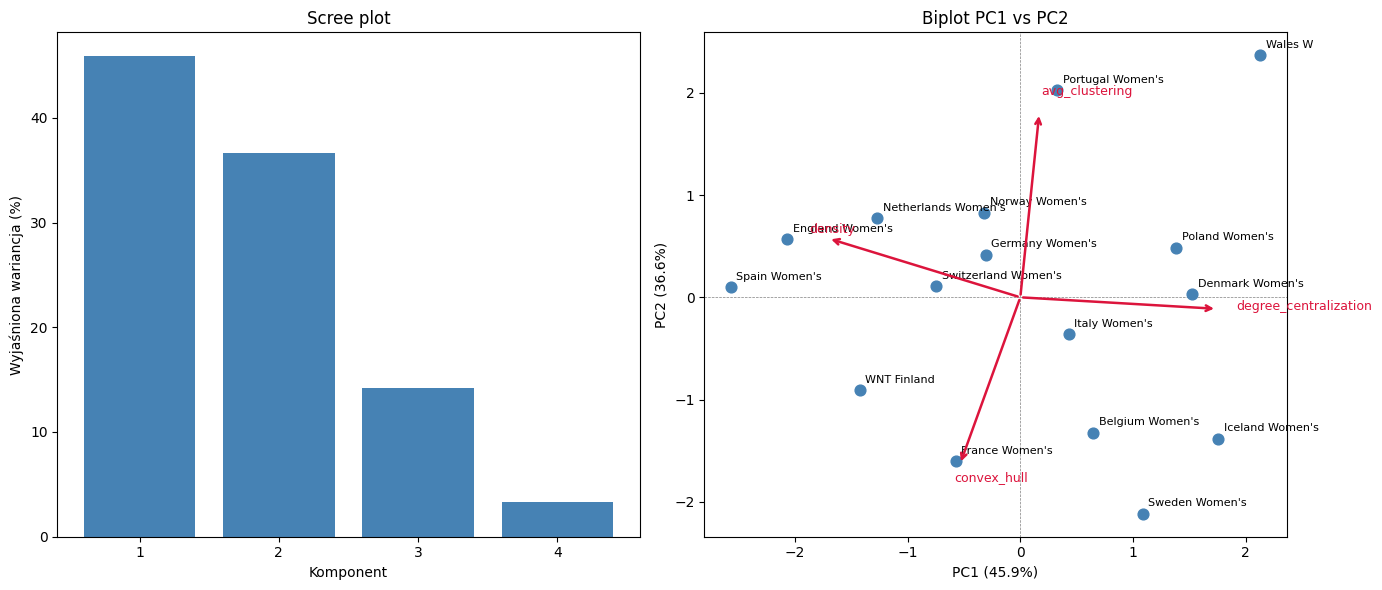

In [248]:


# wykres biplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# lewy panel — scree plot
axes[0].bar(range(1, 5), explained * 100, color='steelblue')
axes[0].set_xlabel('Komponent')
axes[0].set_ylabel('Wyjaśniona wariancja (%)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, 5))

# prawy panel — biplot PC1 vs PC2
ax = axes[1]
ax.scatter(X_pca[:, 0], X_pca[:, 1], color='steelblue', s=60, zorder=3)

# etykiety drużyn
for i, team in enumerate(df4['team']):
    ax.annotate(team, (X_pca[i, 0], X_pca[i, 1]),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')


scale = 2.5
for j, feat in enumerate(features):
    ax.annotate('', 
                xy=(pca.components_[0, j] * scale, pca.components_[1, j] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
    ax.text(pca.components_[0, j] * scale * 1.1,
            pca.components_[1, j] * scale * 1.1,
            feat, color='crimson', fontsize=9)

ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('Biplot PC1 vs PC2')

plt.tight_layout()
plt.savefig('pca_passing_networks.png', dpi=150, bbox_inches='tight')
plt.show()

In [249]:
df5 = pd.DataFrame(X_pca)

In [250]:
df5["team"] = df4["team"]

In [251]:
df5.to_csv("pca_results.csv")

# Team's passing network effects

## Shots

### Traditional Poisson model

In [252]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula="shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -181.94
Date:                Fri, 04 Sep 2026   Deviance:                       99.140
Time:                        23:17:28   Pearson chi2:                     97.2
No. Iterations:                     4   Pseudo R-squ. (CS):             0.6987
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.30

### Multi-level, cross-classified Poisson model

In [253]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M    -0.0496   0.0356                      
density                  M     2.3420   0.0439                      
degree_centralization    M    -1.6478   0.1629                      
convex_hull              M     0.5316   0.0162                      
avg_clustering           M     0.9831   0.1651                      
diameter                 M    -0.1517   0.0171                      
team                     V    -1.8200   0.1846 0.162   0.112   0.234
match                    V    -1.7943   0.1297 0.166   0.128   0.215
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## Shots on target

### Traditional Poisson model

In [26]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       56
Model Family:                     Poisson   Df Model:                            5
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -148.97
Date:                    Thu, 03 Sep 2026   Deviance:                       96.449
Time:                            09:45:19   Pearson chi2:                     101.
No. Iterations:                         4   Pseudo R-squ. (CS):             0.2576
Covariance Type:                nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

### Multi-level, cross-classified Poisson model

In [18]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M     1.3193   0.0565                      
density                  M     1.4102   0.0699                      
degree_centralization    M    -1.9145   0.2554                      
convex_hull              M     0.0564   0.0261                      
avg_clustering           M     0.6080   0.2585                      
diameter                 M    -0.3433   0.0272                      
team                     V    -1.4006   0.1762 0.246   0.173   0.351
match                    V    -1.9112   0.1300 0.148   0.114   0.192
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## xG

### Traditional Poisson model

In [19]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     4.960
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           0.000789
Time:                        09:32:22   Log-Likelihood:                -82.313
No. Observations:                  62   AIC:                             176.6
Df Residuals:                      56   BIC:                             189.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -3.65

### Multi-level cross-classified model

In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula="""
        xG_fotmob ~ 
        density + 
        degree_centralization + 
        convex_hull + 
        avg_clustering + 
        diameter
    """,
    data=df2,
    family=sm.families.Gaussian()
).fit()

print(model.summary())

model.pseudo_rsquared(kind="cs")

                 Generalized Linear Model Regression Results                  
Dep. Variable:              xG_fotmob   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                         0.92235
Method:                          IRLS   Log-Likelihood:                -82.313
Date:                Thu, 03 Sep 2026   Deviance:                       51.652
Time:                        09:33:37   Pearson chi2:                     51.7
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3330
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -3.65

np.float64(0.3330460711022476)

## Goals

### Traditional Poisson model

In [22]:
model = smf.glm(
    formula="goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.560
Date:                Thu, 03 Sep 2026   Deviance:                       53.616
Time:                        09:33:42   Pearson chi2:                     54.2
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3508
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -6.94

### Multi-level, cross-classified Poisson model

In [133]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M    -2.0625   0.0964                      
density                  M     2.0108   0.1186                      
degree_centralization    M    -2.6354   0.4372                      
convex_hull              M     0.6201   0.0437                      
avg_clustering           M    -0.3704   0.4400                      
diameter                 M     0.0998   0.0461                      
team                     V    -1.5405   0.1770 0.214   0.150   0.305
match                    V    -1.3256   0.1287 0.266   0.205   0.344
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


# Opponents passing network effects 

## Shots

### Traditional Poisson model

In [27]:
model = smf.glm(
    formula="shots ~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -175.19
Date:                Thu, 03 Sep 2026   Deviance:                       85.631
Time:                        10:04:15   Pearson chi2:                     84.5
No. Iterations:                     4   Pseudo R-squ. (CS):             0.7577
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [29]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots ~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                          Poisson Mixed GLM Results
                                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------------
Intercept                          M     3.8443   0.0356                      
density_opponents                  M    -1.1541   0.0460                      
degree_centralization_opponents    M     1.1225   0.1461                      
convex_hull_opponents              M    -0.5659   0.0171                      
avg_clustering_opponents           M    -1.9025   0.1643                      
diameter_opponents                 M     0.4110   0.0163                      
team                               V    -1.8458   0.1787 0.158   0.110   0.226
match                              V    -1.9896   0.1302 0.137   0.105   0.177
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## Shots on target

### Traditional Poisson model

In [30]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       56
Model Family:                     Poisson   Df Model:                            5
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -150.22
Date:                    Thu, 03 Sep 2026   Deviance:                       98.934
Time:                            10:07:21   Pearson chi2:                     111.
No. Iterations:                         4   Pseudo R-squ. (CS):             0.2272
Covariance Type:                nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

### Multi-level, cross-classified Poisson model

In [32]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots_on_target_fotmob ~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                          Poisson Mixed GLM Results
                                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------------
Intercept                          M     1.4599   0.0565                      
density_opponents                  M    -0.3284   0.0722                      
degree_centralization_opponents    M     1.6330   0.2329                      
convex_hull_opponents              M    -0.2825   0.0268                      
avg_clustering_opponents           M    -0.1429   0.2569                      
diameter_opponents                 M     0.2889   0.0261                      
team                               V    -1.6137   0.1774 0.199   0.140   0.284
match                              V    -1.7509   0.1296 0.174   0.134   0.225
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## xG

### Traditional model

In [130]:
X = df2[['density_opponents', 'degree_centralization_opponents', 'convex_hull_opponents', 'avg_clustering_opponents', 'diameter_opponents']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     7.033
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           3.67e-05
Time:                        22:33:01   Log-Likelihood:                -78.573
No. Observations:                  62   AIC:                             169.1
Df Residuals:                      56   BIC:                             181.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### Multi-level, cross-classified model

In [61]:
model = bmb.Model(
    formula="""
        xG_fotmob ~ 
        convex_hull_opponents +
        density_opponents + 
        degree_centralization_opponents + 
        avg_clustering_opponents + 
        diameter_opponents +
        (1 | team) +
        (1 | match_id)
    """,
    data=df2,
    family="gaussian"
)

results = model.fit(
    draws=2000,
    tune=1000,
    target_accept=0.9,
    random_seed=42
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, convex_hull_opponents, density_opponents, degree_centralization_opponents, avg_clustering_opponents, diameter_opponents, 1|team_sigma, 1|team_offset, 1|match_id_sigma, 1|match_id_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


In [ ]:
posterior = results["posterior"].to_dataset()

print("=== POSTERIOR SUMMARY ===\n")
print(f"{'Variable':<40} {'mean':>8} {'sd':>8} {'HDI 3%':>10} {'HDI 97%':>10} {'r_hat':>8}")
print("-" * 90)

for var in posterior.data_vars:
    data = posterior[var].values  # shape: (chain, draw) lub (chain, draw, groups)
    n_chains, n_draws = data.shape[0], data.shape[1]
    
    if data.ndim == 2:
        # Fixed effects / sigma — jeden wiersz
        samples = data.flatten()
        mean = samples.mean()
        sd = samples.std()
        hdi_low = np.percentile(samples, 3)
        hdi_high = np.percentile(samples, 97)
        
        # R-hat
        chain_means = data.mean(axis=1)
        chain_vars = data.var(axis=1, ddof=1)
        W = chain_vars.mean()
        B = n_draws * chain_means.var(ddof=1)
        var_hat = (1 - 1/n_draws) * W + B/n_draws
        r_hat = np.sqrt(var_hat / (W + 1e-10))
        
        print(f"{var:<40} {mean:>8.4f} {sd:>8.4f} {hdi_low:>10.4f} {hdi_high:>10.4f} {r_hat:>8.4f}")
    
    elif data.ndim == 3:
        # Random effects — jeden wiersz na grupę
        n_groups = data.shape[2]
        dims = posterior[var].dims
        group_dim = dims[2]
        
        # Nazwy grup jeśli dostępne
        try:
            group_coords = posterior.coords[group_dim].values
        except KeyError:
            group_coords = [f"group_{i}" for i in range(n_groups)]
        
        print(f"\n{var} (random effects):")
        print(f"  {'Group':<30} {'mean':>8} {'sd':>8} {'HDI 3%':>10} {'HDI 97%':>10} {'r_hat':>8}")
        print(f"  {'-'*78}")
        
        for g in range(n_groups):
            samples_g = data[:, :, g].flatten()
            mean = samples_g.mean()
            sd = samples_g.std()
            hdi_low = np.percentile(samples_g, 3)
            hdi_high = np.percentile(samples_g, 97)
            
            # R-hat per group
            chain_data = data[:, :, g]
            chain_means = chain_data.mean(axis=1)
            chain_vars = chain_data.var(axis=1, ddof=1)
            W = chain_vars.mean()
            B = n_draws * chain_means.var(ddof=1)
            var_hat = (1 - 1/n_draws) * W + B/n_draws
            r_hat = np.sqrt(var_hat / (W + 1e-10))
            
            label = str(group_coords[g])
            print(f"  {label:<30} {mean:>8.4f} {sd:>8.4f} {hdi_low:>10.4f} {hdi_high:>10.4f} {r_hat:>8.4f}")
        print()

=== POSTERIOR SUMMARY ===

Variable                                     mean       sd     HDI 3%    HDI 97%    r_hat
------------------------------------------------------------------------------------------
sigma                                      0.7130   0.0909     0.5592     0.9011   1.0017
Intercept                                  3.0063   2.4133    -1.4798     7.6539   1.0001
convex_hull_opponents                     -1.4596   0.3381    -2.1017    -0.8235   1.0006
density_opponents                         -0.2643   2.0445    -4.1832     3.5076   1.0001
degree_centralization_opponents            3.6317   2.1244    -0.3904     7.5743   0.9999
avg_clustering_opponents                   2.7538   2.5229    -2.1047     7.4588   1.0000
diameter_opponents                         0.2493   0.4057    -0.5474     1.0079   0.9998
1|team_sigma                               0.6155   0.1888     0.2979     1.0110   1.0018
1|match_id_sigma                           0.1976   0.1384     0.0098   

## Goals

### Traditional Poisson model

In [66]:
model = smf.glm(
    formula="goals~ density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       56
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -93.451
Date:                Thu, 03 Sep 2026   Deviance:                       59.399
Time:                        10:25:03   Pearson chi2:                     52.1
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2874
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [49]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                     Poisson Mixed GLM Results
                      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------
Intercept                M    -2.0625   0.0964                      
density                  M     2.0108   0.1186                      
degree_centralization    M    -2.6354   0.4372                      
convex_hull              M     0.6201   0.0437                      
avg_clustering           M    -0.3704   0.4400                      
diameter                 M     0.0998   0.0461                      
team                     V    -1.5405   0.1770 0.214   0.150   0.305
match                    V    -1.3256   0.1287 0.266   0.205   0.344
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


# Joint effects

## Shots

### Traditional Poisson

In [69]:
model = smf.glm(
    formula="shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       51
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -158.24
Date:                Thu, 03 Sep 2026   Deviance:                       51.739
Time:                        10:39:36   Pearson chi2:                     52.0
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8597
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [51]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                          Poisson Mixed GLM Results
                                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------------
Intercept                          M     1.5634   0.0356                      
density                            M     1.6094   0.0438                      
degree_centralization              M    -1.1512   0.1631                      
convex_hull                        M     0.4801   0.0162                      
avg_clustering                     M     1.0731   0.1651                      
diameter                           M    -0.1768   0.0171                      
density_opponents                  M    -0.3513   0.0460                      
degree_centralization_opponents    M     0.6749   0.1460                      
convex_hull_opponents              M    -0.5394   0.0171                      
avg_clustering_opponents           M    -2.2635   0.1642                      


## Shots on target 

### Traditional Poisson model

In [70]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       51
Model Family:                     Poisson   Df Model:                           10
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -144.31
Date:                    Thu, 03 Sep 2026   Deviance:                       87.113
Time:                            10:43:54   Pearson chi2:                     97.1
No. Iterations:                         5   Pseudo R-squ. (CS):             0.3614
Covariance Type:                nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

### Multi-level, cross-classified Poisson model

In [53]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                          Poisson Mixed GLM Results
                                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------------
Intercept                          M     1.2050   0.0565                      
density                            M     0.7936   0.0699                      
degree_centralization              M    -1.9223   0.2555                      
convex_hull                        M     0.0062   0.0261                      
avg_clustering                     M     1.1116   0.2592                      
diameter                           M    -0.3933   0.0272                      
density_opponents                  M     0.4503   0.0723                      
degree_centralization_opponents    M     1.4500   0.2328                      
convex_hull_opponents              M    -0.2572   0.0268                      
avg_clustering_opponents           M     0.0998   0.2570                      


/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:1169: RuntimeWarning: overflow encountered in exp
  return -np.exp(tm + np.sqrt(tv) * z)
/Users/user/.pyenv/versions/3.14.2/lib/python3.14/site-packages/statsmodels/genmod/bayes_mixed_glm.py:1184: RuntimeWarning: overflow encountered in exp
  y = -np.exp(tm + np.sqrt(tv) * z)


## xG

### Traditional model

In [71]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter', 'density_opponents', 'degree_centralization_opponents', 'convex_hull_opponents', 'avg_clustering_opponents', 'diameter_opponents']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     5.639
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.27e-05
Time:                        10:45:58   Log-Likelihood:                -70.597
No. Observations:                  62   AIC:                             163.2
Df Residuals:                      51   BIC:                             186.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### Multi-level cross-classified model

In [67]:
model = bmb.Model(
    formula="""
        xG_fotmob ~ 
        density +
        degree_centralization +
        convex_hull + 
        avg_clustering + 
        diameter +
        density_opponents + 
        convex_hull_opponents +
        degree_centralization_opponents + 
        avg_clustering_opponents + 
        diameter_opponents +
        (1 | team) +
        (1 | match_id)
    """,
    data=df2,
    family="gaussian"
)

results = model.fit(
    draws=2000,
    tune=1000,
    target_accept=0.9,
    random_seed=42
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, density, degree_centralization, convex_hull, avg_clustering, diameter, density_opponents, convex_hull_opponents, degree_centralization_opponents, avg_clustering_opponents, diameter_opponents, 1|team_sigma, 1|team_offset, 1|match_id_sigma, 1|match_id_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


In [68]:
posterior = results["posterior"].to_dataset()

print("=== POSTERIOR SUMMARY ===\n")
print(f"{'Variable':<40} {'mean':>8} {'sd':>8} {'HDI 3%':>10} {'HDI 97%':>10} {'r_hat':>8}")
print("-" * 90)

for var in posterior.data_vars:
    data = posterior[var].values  # shape: (chain, draw) lub (chain, draw, groups)
    n_chains, n_draws = data.shape[0], data.shape[1]
    
    if data.ndim == 2:
        # Fixed effects / sigma — jeden wiersz
        samples = data.flatten()
        mean = samples.mean()
        sd = samples.std()
        hdi_low = np.percentile(samples, 3)
        hdi_high = np.percentile(samples, 97)
        
        # R-hat
        chain_means = data.mean(axis=1)
        chain_vars = data.var(axis=1, ddof=1)
        W = chain_vars.mean()
        B = n_draws * chain_means.var(ddof=1)
        var_hat = (1 - 1/n_draws) * W + B/n_draws
        r_hat = np.sqrt(var_hat / (W + 1e-10))
        
        print(f"{var:<40} {mean:>8.4f} {sd:>8.4f} {hdi_low:>10.4f} {hdi_high:>10.4f} {r_hat:>8.4f}")
    
    elif data.ndim == 3:
        # Random effects — jeden wiersz na grupę
        n_groups = data.shape[2]
        dims = posterior[var].dims
        group_dim = dims[2]
        
        # Nazwy grup jeśli dostępne
        try:
            group_coords = posterior.coords[group_dim].values
        except KeyError:
            group_coords = [f"group_{i}" for i in range(n_groups)]
        
        print(f"\n{var} (random effects):")
        print(f"  {'Group':<30} {'mean':>8} {'sd':>8} {'HDI 3%':>10} {'HDI 97%':>10} {'r_hat':>8}")
        print(f"  {'-'*78}")
        
        for g in range(n_groups):
            samples_g = data[:, :, g].flatten()
            mean = samples_g.mean()
            sd = samples_g.std()
            hdi_low = np.percentile(samples_g, 3)
            hdi_high = np.percentile(samples_g, 97)
            
            # R-hat per group
            chain_data = data[:, :, g]
            chain_means = chain_data.mean(axis=1)
            chain_vars = chain_data.var(axis=1, ddof=1)
            W = chain_vars.mean()
            B = n_draws * chain_means.var(ddof=1)
            var_hat = (1 - 1/n_draws) * W + B/n_draws
            r_hat = np.sqrt(var_hat / (W + 1e-10))
            
            label = str(group_coords[g])
            print(f"  {label:<30} {mean:>8.4f} {sd:>8.4f} {hdi_low:>10.4f} {hdi_high:>10.4f} {r_hat:>8.4f}")
        print()

=== POSTERIOR SUMMARY ===

Variable                                     mean       sd     HDI 3%    HDI 97%    r_hat
------------------------------------------------------------------------------------------
sigma                                      0.6753   0.0883     0.5323     0.8602   1.0016
Intercept                                 -1.6609   3.3799    -8.1561     4.8069   0.9998
density                                    2.4782   1.9345    -1.1033     6.1706   1.0000
degree_centralization                     -3.3204   1.9204    -6.9748     0.2731   1.0000
convex_hull                                0.4845   0.3963    -0.2630     1.2227   1.0004
avg_clustering                             1.2945   2.4897    -3.4220     5.8927   1.0001
diameter                                   0.1763   0.3938    -0.5611     0.9338   1.0000
density_opponents                          1.6827   2.0086    -2.1085     5.4853   1.0002
convex_hull_opponents                     -1.3412   0.3215    -1.9415   

## Goals

### Traditional Poisson model

In [72]:
model = smf.glm(
    formula="goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       51
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -84.262
Date:                Thu, 03 Sep 2026   Deviance:                       41.020
Time:                        10:48:30   Pearson chi2:                     38.3
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4702
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Multi-level, cross-classified Poisson model

In [57]:
random_effects = {
    "team": "0 + C(team)",
    "match": "0 + C(match_id)"
}

model_cc = PoissonBayesMixedGLM.from_formula(
    "goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter + density_opponents + degree_centralization_opponents + convex_hull_opponents + avg_clustering_opponents + diameter_opponents",
    random_effects,
    df2
)

result_cc = model_cc.fit_vb()

print(result_cc.summary())

                          Poisson Mixed GLM Results
                                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------------
Intercept                          M    -1.1937   0.0965                      
density                            M     1.7635   0.1185                      
degree_centralization              M    -2.2204   0.4402                      
convex_hull                        M     0.5810   0.0437                      
avg_clustering                     M     0.8263   0.4458                      
diameter                           M     0.1383   0.0461                      
density_opponents                  M     0.1474   0.1243                      
degree_centralization_opponents    M     0.6632   0.3880                      
convex_hull_opponents              M    -0.9414   0.0478                      
avg_clustering_opponents           M     0.0361   0.4223                      


# Interaction analysis

### Density + accurate passes

In [261]:
df2["density_accurate"] = df2["density"] * df2["accurate_passes_perc_fotmob"]
df2["convex_accurate"] = df2["convex_hull"] * df2["accurate_passes_perc_fotmob"]
df2["avg_clustering_accurate"] = df2["avg_clustering"] * df2["accurate_passes_perc_fotmob"]
df2["centralization_accurate"] = df2["degree_centralization"] * df2["accurate_passes_perc_fotmob"]

#### Centering

In [256]:
df2["density_cent"] = df2["density"] - df2["density"].mean()
df2["centralization_cent"] = df2["degree_centralization"] - df2["degree_centralization"].mean()
df2["convex_cent"] = df2["convex_hull"] - df2["convex_hull"].mean()
df2["avg_clustering_cent"] = df2["avg_clustering"] - df2["avg_clustering"].mean()
df2["diameter_cent"] = df2["diameter"] - df2["diameter"].mean()
df2["accurate_cent"] = df2["accurate_passes_perc_fotmob"] - df2["accurate_passes_perc_fotmob"].mean()

#### Low and high levels + 1 SD -1 SD

In [259]:
df2["density_low"] = df2["density_cent"] + df2["density"].std()
df2["density_high"] = df2["density_cent"] - df2["density"].std()

df2["centralization_low"] = df2["centralization_cent"] + df2["degree_centralization"].std()
df2["centralization_high"] = df2["centralization_cent"] - df2["degree_centralization"].std()

df2["convex_low"] = df2["convex_cent"] + df2["convex_hull"].std()
df2["convex_high"] = df2["convex_cent"] - df2["convex_hull"].std()

df2["avg_clustering_low"] = df2["avg_clustering_cent"] + df2["avg_clustering"].std()
df2["avg_clustering_high"] = df2["avg_clustering_cent"] - df2["avg_clustering"].std()

df2["diameter_low"] = df2["diameter_cent"] + df2["diameter"].std()
df2["diameter_high"] = df2["diameter_cent"] - df2["diameter"].std()

df2["accurate_low"] = df2["accurate_cent"] + df2["accurate_passes_perc_fotmob"].std()
df2["accurate_high"] = df2["accurate_cent"] - df2["accurate_passes_perc_fotmob"].std()



#### Shots

In [262]:
model = smf.glm(
    formula="shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + density_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -166.35
Date:                Fri, 04 Sep 2026   Deviance:                       67.951
Time:                        23:28:05   Pearson chi2:                     68.4
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8178
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [263]:
df2["density_accurate_cent"] = df2["density_cent"]*df2["accurate_cent"]

In [264]:
model = smf.glm(
    formula="shots ~ density_cent + centralization_cent + convex_cent + avg_clustering_cent + diameter_cent + accurate_cent + density_accurate_cent",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -166.35
Date:                Fri, 04 Sep 2026   Deviance:                       67.951
Time:                        23:29:50   Pearson chi2:                     68.4
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8178
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.40

In [267]:
df2["density_accurate_low"] = df2["density_cent"]*df2["accurate_low"]

In [272]:
model = smf.glm(
    formula="shots ~ density_cent + centralization_cent + convex_cent + avg_clustering_cent + diameter_cent + accurate_low + density_accurate_low",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -166.35
Date:                Fri, 04 Sep 2026   Deviance:                       67.951
Time:                        23:32:51   Pearson chi2:                     68.4
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8178
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.0249 

In [273]:
df2["density_accurate_high"] = df2["density_cent"]*df2["accurate_high"] 

In [274]:
model = smf.glm(
    formula="shots ~ density_cent + centralization_cent + convex_cent + avg_clustering_cent + diameter_cent + accurate_high + density_accurate_high",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -166.35
Date:                Fri, 04 Sep 2026   Deviance:                       67.951
Time:                        23:33:00   Pearson chi2:                     68.4
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8178
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.78

#### Shots on target

In [181]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + density_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       54
Model Family:                     Poisson   Df Model:                            7
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -147.05
Date:                    Fri, 04 Sep 2026   Deviance:                       92.601
Time:                            22:53:55   Pearson chi2:                     103.
No. Iterations:                         4   Pseudo R-squ. (CS):             0.3023
Covariance Type:                nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

#### xG

In [275]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter', 'accurate_passes_perc_fotmob', 'density_accurate']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     5.202
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           0.000142
Time:                        23:33:24   Log-Likelihood:                -77.702
No. Observations:                  62   AIC:                             171.4
Df Residuals:                      54   BIC:                             188.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [278]:
X = df2[['density_cent', 'centralization_cent', 'convex_cent', 'avg_clustering_cent', 'diameter_cent', 'accurate_cent', 'density_accurate_cent']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     5.202
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           0.000142
Time:                        23:34:26   Log-Likelihood:                -77.702
No. Observations:                  62   AIC:                             171.4
Df Residuals:                      54   BIC:                             188.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.53

In [279]:
X = df2[['density_cent', 'centralization_cent', 'convex_cent', 'avg_clustering_cent', 'diameter_cent', 'accurate_low', 'density_accurate_low']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     5.202
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           0.000142
Time:                        23:34:54   Log-Likelihood:                -77.702
No. Observations:                  62   AIC:                             171.4
Df Residuals:                      54   BIC:                             188.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.0651 

In [280]:
X = df2[['density_cent', 'centralization_cent', 'convex_cent', 'avg_clustering_cent', 'diameter_cent', 'accurate_high', 'density_accurate_high']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     5.202
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           0.000142
Time:                        23:35:19   Log-Likelihood:                -77.702
No. Observations:                  62   AIC:                             171.4
Df Residuals:                      54   BIC:                             188.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.99

#### Goals

In [183]:
model = smf.glm(
    formula="goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + density_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -89.168
Date:                Fri, 04 Sep 2026   Deviance:                       50.833
Time:                        22:55:00   Pearson chi2:                     51.4
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3793
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

### Centralization & accurate passes

#### Shots

In [185]:
model = smf.glm(
    formula="shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + centralization_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -165.63
Date:                Fri, 04 Sep 2026   Deviance:                       66.518
Time:                        22:57:06   Pearson chi2:                     66.8
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8220
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

#### Shots on target

In [187]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + centralization_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       54
Model Family:                     Poisson   Df Model:                            7
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -147.15
Date:                    Fri, 04 Sep 2026   Deviance:                       92.810
Time:                            22:58:11   Pearson chi2:                     99.1
No. Iterations:                         5   Pseudo R-squ. (CS):             0.2999
Covariance Type:                nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

#### xG

In [191]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter', 'accurate_passes_perc_fotmob', 'centralization_accurate']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     4.289
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           0.000783
Time:                        22:59:43   Log-Likelihood:                -79.974
No. Observations:                  62   AIC:                             175.9
Df Residuals:                      54   BIC:                             193.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

### Goals

In [190]:
model = smf.glm(
    formula="goals ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + centralization_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.284
Date:                Fri, 04 Sep 2026   Deviance:                       53.064
Time:                        22:59:08   Pearson chi2:                     53.2
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3566
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

### Average clustering + accurate passes

#### Shots

In [192]:
model = smf.glm(
    formula="shots ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + avg_clustering_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -167.67
Date:                Fri, 04 Sep 2026   Deviance:                       70.591
Time:                        23:01:56   Pearson chi2:                     69.0
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8099
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

#### Shots on target

In [194]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + avg_clustering_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       54
Model Family:                     Poisson   Df Model:                            7
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -146.72
Date:                    Fri, 04 Sep 2026   Deviance:                       91.935
Time:                            23:02:16   Pearson chi2:                     95.5
No. Iterations:                         5   Pseudo R-squ. (CS):             0.3097
Covariance Type:                nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

#### xG

In [196]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter', 'accurate_passes_perc_fotmob', 'avg_clustering_accurate']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     4.278
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           0.000800
Time:                        23:02:46   Log-Likelihood:                -80.003
No. Observations:                  62   AIC:                             176.0
Df Residuals:                      54   BIC:                             193.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

#### Goals

In [195]:
model = smf.glm(
    formula="goals~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + avg_clustering_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.403
Date:                Fri, 04 Sep 2026   Deviance:                       53.301
Time:                        23:02:26   Pearson chi2:                     53.5
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3541
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

### Convex hull & accurate passes

#### Shots

In [197]:
model = smf.glm(
    formula="shots~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + convex_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  shots   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -167.90
Date:                Fri, 04 Sep 2026   Deviance:                       71.063
Time:                        23:04:14   Pearson chi2:                     70.2
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8084
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

#### Shots on target

In [199]:
model = smf.glm(
    formula="shots_on_target_fotmob ~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + convex_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     shots_on_target_fotmob   No. Observations:                   62
Model:                                GLM   Df Residuals:                       54
Model Family:                     Poisson   Df Model:                            7
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -147.12
Date:                    Fri, 04 Sep 2026   Deviance:                       92.733
Time:                            23:05:04   Pearson chi2:                     97.2
No. Iterations:                         5   Pseudo R-squ. (CS):             0.3008
Covariance Type:                nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

#### xG

In [201]:
X = df2[['density', 'degree_centralization', 'convex_hull', 'avg_clustering', 'diameter', 'accurate_passes_perc_fotmob', 'convex_accurate']]
Y = df2['xG_fotmob']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              xG_fotmob   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     4.291
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           0.000780
Time:                        23:06:05   Log-Likelihood:                -79.969
No. Observations:                  62   AIC:                             175.9
Df Residuals:                      54   BIC:                             193.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

#### Goals

In [200]:
model = smf.glm(
    formula="goals~ density + degree_centralization + convex_hull + avg_clustering + diameter + accurate_passes_perc_fotmob + convex_accurate",
    data=df2,
    family=sm.families.Poisson()
).fit()

print(model.summary())
r2_cs = model.pseudo_rsquared(kind="cs")
print(r2_cs)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                   62
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.232
Date:                Fri, 04 Sep 2026   Deviance:                       52.960
Time:                        23:05:25   Pearson chi2:                     53.8
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3577
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [178]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

predictors = [
    'density',
    'degree_centralization',
    'convex_hull',
    'avg_clustering',
    'diameter',
    'density_opponents',
    'degree_centralization_opponents',
    'convex_hull_opponents',
    'avg_clustering_opponents',
    'diameter_opponents'
]

X = df2[predictors].dropna()
X = sm.add_constant(X)


vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print(vif)


                           variable          VIF
0                             const  1011.859778
1                           density     2.285883
2             degree_centralization     1.807423
3                       convex_hull     1.241250
4                    avg_clustering     1.446890
5                          diameter     1.317805
6                 density_opponents     2.285883
7   degree_centralization_opponents     1.807423
8             convex_hull_opponents     1.241250
9          avg_clustering_opponents     1.446890
10               diameter_opponents     1.317805
